In [73]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from scipy import stats
from Lasso import select_features_lasso

In [74]:
df = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed']

In [75]:
cols_to_remove = ['BrO_Error', 'NO2_Error', 'O3_Error']
data = df.drop(columns = cols_to_remove)

In [76]:
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [77]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)
data = data.dropna(subset=['target_precipitation'])

In [78]:
r2 = r2_score(data['target_precipitation'], data['tp'])
r2

0.4183687040052195

# Vėlavimų atrinkimas

In [79]:
def metrics_fun(y_val, rf_pred_val):
    print(f'R^2:  {r2_score(y_val, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val, rf_pred_val))}')

    corr, p_value = stats.spearmanr(y_val, rf_pred_val)
    print(f"r_s:  {corr:.3f}")

In [80]:
train_end = '2024-02-01'
val_end = '2025-02-01'

# train = data[data['observationTime'] < train_end]
# val   = data[(data['observationTime'] >= train_end) & (data['observationTime'] <= val_end)]
# test  = data[data['observationTime'] > val_end]

# print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
# print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
# print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

In [81]:
target_col = 'target_precipitation'
drop_cols = ['missforest_precipitation','observationTime', 't2m', target_col]

# X_train = train.drop(columns=drop_cols)
# y_train = train[target_col]

# X_val = val.drop(columns=drop_cols)
# y_val = val[target_col]

# X_test = test.drop(columns=drop_cols)
# y_test = test[target_col]

In [82]:
def test_lag(data, feature_col, lag, base_features, target_col, train_end, val_end):
    df = data.copy()
    
    if lag == 0:
        # Originali reikšmė - nieko nekeičiam
        features = base_features
    else:
        # Pakeičiam originalų požymį jo lagu
        lag_col = f'{feature_col}_lag{lag}'
        df[lag_col] = df[feature_col].shift(lag)
        df = df.dropna().reset_index(drop=True)
        
        # Pakeičiam originalų į laginį
        features = [f for f in base_features if f != feature_col] + [lag_col]
    
    train = df[df['observationTime'] < train_end]
    val   = df[(df['observationTime'] >= train_end) & (df['observationTime'] <= val_end)]
    
    model = XGBRegressor(random_state=2026)
    model.fit(train[features], train[target_col])
    
    pred = model.predict(val[features])
    return np.sqrt(mean_absolute_error(val[target_col], pred))

base_features = ['absorbing_aerosol_index', 'NO2_column_number_density',
       'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'pm10', 'pm2p5', 'sia',
       'nmvoc', 'dust', 'nh3', 'pans', 'airTemperature',
       'seaLevelPressure', 'relativeHumidity', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed']

results = []
for col in base_features:
    for lag in range(0, 10):  # 0 = originali
        mae = test_lag(data, col, lag, base_features, 'target_precipitation', train_end, val_end)
        label = 'originali' if lag == 0 else f'lag{lag}'
        results.append({'feature': col, 'lag': lag, 'label': label, 'mae': mae})
        print(f"{col} {label}: MAE = {mae:.4f}")

results_df = pd.DataFrame(results)

print("\n=== Suvestinė ===")
for col in results_df['feature'].unique():
    subset = results_df[results_df['feature'] == col]
    best = subset.loc[subset['mae'].idxmin()]
    orig_mae = subset[subset['lag'] == 0]['mae'].values[0]
    print(f"\n{col}:")
    print(f"  Originali : {orig_mae:.4f}")
    print(f"  Geriausias: {best['label']} → {best['mae']:.4f}")

absorbing_aerosol_index originali: MAE = 1.5937
absorbing_aerosol_index lag1: MAE = 1.6151
absorbing_aerosol_index lag2: MAE = 1.6083
absorbing_aerosol_index lag3: MAE = 1.6302
absorbing_aerosol_index lag4: MAE = 1.6024
absorbing_aerosol_index lag5: MAE = 1.5976
absorbing_aerosol_index lag6: MAE = 1.6180
absorbing_aerosol_index lag7: MAE = 1.5924
absorbing_aerosol_index lag8: MAE = 1.5402
absorbing_aerosol_index lag9: MAE = 1.6155
NO2_column_number_density originali: MAE = 1.5937
NO2_column_number_density lag1: MAE = 1.7118
NO2_column_number_density lag2: MAE = 1.6707
NO2_column_number_density lag3: MAE = 1.6717
NO2_column_number_density lag4: MAE = 1.6825
NO2_column_number_density lag5: MAE = 1.6181
NO2_column_number_density lag6: MAE = 1.6892
NO2_column_number_density lag7: MAE = 1.6777
NO2_column_number_density lag8: MAE = 1.7222
NO2_column_number_density lag9: MAE = 1.7406
stratospheric_NO2_column_number_density originali: MAE = 1.5937
stratospheric_NO2_column_number_density lag1: 

In [83]:

def add_specific_lags(df):
    df = df.copy()
    
    df['absorbing_aerosol_index_lag6'] = df['absorbing_aerosol_index'].shift(6)
    # df['NO2_column_number_density_lag11'] = df['NO2_column_number_density'].shift(11)
    df['stratospheric_NO2_column_number_density_lag10'] = df['stratospheric_NO2_column_number_density'].shift(10)
    df['NO2_slant_column_number_density_lag1'] = df['NO2_slant_column_number_density'].shift(1)
    # df['tropopause_pressure_lag8'] = df['tropopause_pressure'].shift(8)
    df['H2O_column_number_density_lag10'] = df['H2O_column_number_density'].shift(10)
    df['BrO_lag5'] = df['BrO'].shift(5)
    # df['NO2_lag10'] = df['NO2'].shift(10)
    df['O3_lag4'] = df['O3'].shift(4)
    df['pm10_lag8'] = df['pm10'].shift(8)
    # df['pm2p5_lag3'] = df['pm2p5'].shift(3)
    df['sia_lag5'] = df['sia'].shift(5)
    df['nmvoc_lag9'] = df['nmvoc'].shift(9)
    df['dust_lag9'] = df['dust'].shift(9)
    # df['nh3_lag9'] = df['nh3'].shift(9)
    df['pans_lag2'] = df['pans'].shift(2)
    # df['airTemperature_lag9'] = df['airTemperature'].shift(9)
    # df['seaLevelPressure_lag1'] = df['seaLevelPressure'].shift(1)
    # df['relativeHumidity_lag_lag10'] = df['relativeHumidity'].shift(10)
    # df['xgb_cloudCover_lag3'] = df['xgb_cloudCover'].shift(3)
    # df['feelsLikeTemperature_fixed_lag10'] = df['feelsLikeTemperature_fixed'].shift(10)
    # df['windSpeed_fixed_lag1'] = df['windSpeed_fixed'].shift(1)
    # df['windGust_fixed_lag8'] = df['windGust_fixed'].shift(8)
    # df['windDirection_fixed_lag6'] = df['windDirection_fixed'].shift(6)

    
    
    return df

data_with_lags = add_specific_lags(data)
data_with_lags = data_with_lags.dropna().reset_index(drop=True)

In [84]:
original_pollutants = [
    'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    # 'tropopause_pressure',
    'H2O_column_number_density',
    'BrO',
    # 'NO2',
    'O3',
    # 'pm10',
    'pm2p5',
    'sia',
    'nmvoc',
    'dust',
    # 'nh3',
    'pans',
    # 'airTemperature',
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed'
]

data_with_lags = data_with_lags.drop(columns=original_pollutants)

In [85]:
train = data_with_lags[data_with_lags['observationTime'] < train_end]
val   = data_with_lags[(data_with_lags['observationTime'] >= train_end) & (data_with_lags['observationTime'] <= val_end)]
test  = data_with_lags[data_with_lags['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2031, 32), nuo 2018-07-11 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 32), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 32),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [86]:
X_train = train.drop(columns=drop_cols)
y_train = train[target_col]

X_val = val.drop(columns=drop_cols)
y_val = val[target_col]

X_test = test.drop(columns=drop_cols)
y_test = test[target_col]

In [ ]:
# train_for_lasso = X_train.copy()
# train_for_lasso[target_col] = y_train

# selected_features = select_features_lasso(train_for_lasso, target_col)


# X_train_selected = X_train[selected_features]
# X_val_selected   = X_val[selected_features]
# X_test_selected  = X_test[selected_features]

# stand_model = XGBRegressor(random_state=2026)
# stand_model.fit(X_train_selected, y_train)

# val_preds_stand = stand_model.predict(X_val_selected)
# metrics_fun(y_val, val_preds_stand)

Pradinis požymių skaičius: 28
Išlikusių požymių skaičius: 7
Geriausias lambda (alpha): 0.1261
Pašalinti požymiai: ['BrO_lag5', 'day_of_week', 'relativeHumidity_lag_lag10', 'absorbing_aerosol_index_lag6', 'day_of_year', 'dust_lag9', 'pm10_lag8', 'month', 'windGust_fixed_lag8', 'H2O_column_number_density_lag10', 'NO2', 'windSpeed_fixed_lag1', 'airTemperature_lag9', 'windDirection_fixed_lag6', 'seaLevelPressure_lag1', 'O3_lag4', 'xgb_cloudCover_lag3', 'nh3', 'nmvoc_lag9', 'NO2_slant_column_number_density_lag1', 'sia_lag5']
R^2:  0.21213388825778112
MAE:  1.663987748211945
RMSE: 4.285939584478237
r_s:  0.626


In [ ]:
import optuna

def objective(trial):
    df = data.copy()
    features = list(base_features)
    
    for col in base_features:
        lag = trial.suggest_int(f'lag_{col}', 0, 10)
        if lag > 0:
            lag_col = f'{col}_lag{lag}'
            df[lag_col] = df[col].shift(lag)
            features = [f for f in features if f != col] + [lag_col]
    
    df = df.dropna().reset_index(drop=True)
    
    train = df[df['observationTime'] < train_end]
    val   = df[(df['observationTime'] >= train_end) & (df['observationTime'] <= val_end)]
    
    model = XGBRegressor(random_state=2026)
    model.fit(train[features], train[target_col])
    pred = model.predict(val[features])
    
    return mean_absolute_error(val[target_col], pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Geriausi lagai:")
print(study.best_params)

[I 2026-05-11 19:10:14,517] A new study created in memory with name: no-name-0c8bfe27-e789-4c0b-8087-acd0466d8d4c
Best trial: 0. Best value: 2.72838:   0%|          | 1/200 [00:00<00:46,  4.31it/s]

[I 2026-05-11 19:10:14,772] Trial 0 finished with value: 2.7283835939474264 and parameters: {'lag_absorbing_aerosol_index': 0, 'lag_NO2_column_number_density': 5, 'lag_stratospheric_NO2_column_number_density': 3, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 7, 'lag_BrO': 7, 'lag_NO2': 10, 'lag_O3': 5, 'lag_pm10': 2, 'lag_pm2p5': 10, 'lag_sia': 9, 'lag_nmvoc': 7, 'lag_dust': 9, 'lag_nh3': 10, 'lag_pans': 6, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 5, 'lag_relativeHumidity': 0, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 5}. Best is trial 0 with value: 2.7283835939474264.


Best trial: 0. Best value: 2.72838:   1%|          | 2/200 [00:00<00:43,  4.55it/s]

[I 2026-05-11 19:10:14,984] Trial 1 finished with value: 2.9375015344623 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 2, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 6, 'lag_pm2p5': 4, 'lag_sia': 9, 'lag_nmvoc': 3, 'lag_dust': 0, 'lag_nh3': 4, 'lag_pans': 9, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 6, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 10, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 10, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 4}. Best is trial 0 with value: 2.7283835939474264.


Best trial: 2. Best value: 2.67914:   2%|▏         | 3/200 [00:00<00:43,  4.55it/s]

[I 2026-05-11 19:10:15,203] Trial 2 finished with value: 2.6791428277213174 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 4, 'lag_BrO': 3, 'lag_NO2': 3, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 6, 'lag_sia': 9, 'lag_nmvoc': 8, 'lag_dust': 10, 'lag_nh3': 9, 'lag_pans': 0, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 7, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 7, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 8, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 7}. Best is trial 2 with value: 2.6791428277213174.


Best trial: 3. Best value: 2.59468:   2%|▏         | 4/200 [00:00<00:41,  4.72it/s]

[I 2026-05-11 19:10:15,404] Trial 3 finished with value: 2.5946789940103527 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 2, 'lag_stratospheric_NO2_column_number_density': 0, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 4, 'lag_BrO': 4, 'lag_NO2': 7, 'lag_O3': 0, 'lag_pm10': 3, 'lag_pm2p5': 0, 'lag_sia': 8, 'lag_nmvoc': 2, 'lag_dust': 9, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 9}. Best is trial 3 with value: 2.5946789940103527.


Best trial: 3. Best value: 2.59468:   2%|▎         | 5/200 [00:01<00:40,  4.81it/s]

[I 2026-05-11 19:10:15,605] Trial 4 finished with value: 2.6493779834230464 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 2, 'lag_BrO': 3, 'lag_NO2': 9, 'lag_O3': 5, 'lag_pm10': 1, 'lag_pm2p5': 2, 'lag_sia': 0, 'lag_nmvoc': 10, 'lag_dust': 3, 'lag_nh3': 8, 'lag_pans': 4, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 6, 'lag_relativeHumidity': 1, 'lag_xgb_cloudCover': 8, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 0, 'lag_windDirection_fixed': 0}. Best is trial 3 with value: 2.5946789940103527.


Best trial: 3. Best value: 2.59468:   3%|▎         | 6/200 [00:01<00:41,  4.65it/s]

[I 2026-05-11 19:10:15,832] Trial 5 finished with value: 2.7329898570966207 and parameters: {'lag_absorbing_aerosol_index': 0, 'lag_NO2_column_number_density': 7, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 7, 'lag_BrO': 7, 'lag_NO2': 9, 'lag_O3': 10, 'lag_pm10': 0, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 5, 'lag_dust': 1, 'lag_nh3': 2, 'lag_pans': 10, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 8, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 2}. Best is trial 3 with value: 2.5946789940103527.


Best trial: 6. Best value: 2.54432:   4%|▎         | 7/200 [00:01<00:41,  4.60it/s]

[I 2026-05-11 19:10:16,054] Trial 6 finished with value: 2.5443193049497435 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 6, 'lag_BrO': 1, 'lag_NO2': 9, 'lag_O3': 1, 'lag_pm10': 0, 'lag_pm2p5': 0, 'lag_sia': 9, 'lag_nmvoc': 2, 'lag_dust': 7, 'lag_nh3': 6, 'lag_pans': 5, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 10, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 9}. Best is trial 6 with value: 2.5443193049497435.


[I 2026-05-11 19:10:16,242] Trial 7 finished with value: 2.6445668386719228 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 3, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 7, 'lag_BrO': 5, 'lag_NO2': 5, 'lag_O3': 4, 'lag_pm10': 10, 'lag_pm2p5': 6, 'lag_sia': 4, 'lag_nmvoc': 0, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 7, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 3, 'lag_windDirection_fixed': 2}. Best is trial 6 with value: 2.5443193049497435.


Best trial: 6. Best value: 2.54432:   4%|▍         | 9/200 [00:01<00:38,  5.01it/s]

[I 2026-05-11 19:10:16,425] Trial 8 finished with value: 2.8526299919547355 and parameters: {'lag_absorbing_aerosol_index': 0, 'lag_NO2_column_number_density': 3, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 6, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 6, 'lag_BrO': 3, 'lag_NO2': 9, 'lag_O3': 2, 'lag_pm10': 2, 'lag_pm2p5': 0, 'lag_sia': 1, 'lag_nmvoc': 9, 'lag_dust': 5, 'lag_nh3': 9, 'lag_pans': 1, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 9, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 6 with value: 2.5443193049497435.


Best trial: 6. Best value: 2.54432:   5%|▌         | 10/200 [00:02<00:38,  4.97it/s]

[I 2026-05-11 19:10:16,629] Trial 9 finished with value: 2.5567760324821247 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 6, 'lag_BrO': 8, 'lag_NO2': 5, 'lag_O3': 8, 'lag_pm10': 7, 'lag_pm2p5': 9, 'lag_sia': 3, 'lag_nmvoc': 0, 'lag_dust': 10, 'lag_nh3': 10, 'lag_pans': 4, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 8, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 0, 'lag_windDirection_fixed': 9}. Best is trial 6 with value: 2.5443193049497435.


Best trial: 10. Best value: 2.52025:   6%|▌         | 11/200 [00:02<00:49,  3.84it/s]

[I 2026-05-11 19:10:17,023] Trial 10 finished with value: 2.520254101984112 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 7, 'lag_O3': 0, 'lag_pm10': 4, 'lag_pm2p5': 3, 'lag_sia': 6, 'lag_nmvoc': 4, 'lag_dust': 6, 'lag_nh3': 6, 'lag_pans': 8, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 4, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 10, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 10}. Best is trial 10 with value: 2.520254101984112.


Best trial: 10. Best value: 2.52025:   6%|▌         | 12/200 [00:02<00:48,  3.89it/s]

[I 2026-05-11 19:10:17,274] Trial 11 finished with value: 2.6882332221541443 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 7, 'lag_O3': 0, 'lag_pm10': 4, 'lag_pm2p5': 3, 'lag_sia': 6, 'lag_nmvoc': 4, 'lag_dust': 6, 'lag_nh3': 6, 'lag_pans': 8, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 4, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 10, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 10}. Best is trial 10 with value: 2.520254101984112.


Best trial: 12. Best value: 2.48772:   6%|▋         | 13/200 [00:02<00:45,  4.12it/s]

[I 2026-05-11 19:10:17,481] Trial 12 finished with value: 2.4877164573659893 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 7, 'lag_O3': 2, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 7, 'lag_nmvoc': 6, 'lag_dust': 6, 'lag_nh3': 6, 'lag_pans': 5, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 9, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 12 with value: 2.4877164573659893.


Best trial: 13. Best value: 2.28382:   7%|▋         | 14/200 [00:03<00:45,  4.12it/s]

[I 2026-05-11 19:10:17,725] Trial 13 finished with value: 2.2838192549189023 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 3, 'lag_pm10': 5, 'lag_pm2p5': 2, 'lag_sia': 7, 'lag_nmvoc': 6, 'lag_dust': 4, 'lag_nh3': 7, 'lag_pans': 7, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:   8%|▊         | 15/200 [00:03<00:43,  4.27it/s]

[I 2026-05-11 19:10:17,941] Trial 14 finished with value: 2.4361711604251686 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 9, 'lag_BrO': 10, 'lag_NO2': 3, 'lag_O3': 3, 'lag_pm10': 5, 'lag_pm2p5': 2, 'lag_sia': 7, 'lag_nmvoc': 7, 'lag_dust': 3, 'lag_nh3': 7, 'lag_pans': 3, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:   8%|▊         | 16/200 [00:03<00:43,  4.20it/s]

[I 2026-05-11 19:10:18,187] Trial 15 finished with value: 2.535342322040745 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 3, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 9, 'lag_BrO': 10, 'lag_NO2': 3, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 5, 'lag_sia': 7, 'lag_nmvoc': 7, 'lag_dust': 3, 'lag_nh3': 8, 'lag_pans': 3, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 3, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:   8%|▊         | 17/200 [00:03<00:44,  4.12it/s]

[I 2026-05-11 19:10:18,441] Trial 16 finished with value: 2.864116460579252 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 8, 'lag_BrO': 9, 'lag_NO2': 3, 'lag_O3': 7, 'lag_pm10': 6, 'lag_pm2p5': 4, 'lag_sia': 3, 'lag_nmvoc': 6, 'lag_dust': 3, 'lag_nh3': 7, 'lag_pans': 3, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 4}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:   9%|▉         | 18/200 [00:04<00:43,  4.17it/s]

[I 2026-05-11 19:10:18,673] Trial 17 finished with value: 2.6407947772931135 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 0, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 7, 'lag_H2O_column_number_density': 9, 'lag_BrO': 6, 'lag_NO2': 2, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 8, 'lag_sia': 10, 'lag_nmvoc': 8, 'lag_dust': 4, 'lag_nh3': 4, 'lag_pans': 6, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  10%|▉         | 19/200 [00:04<00:41,  4.32it/s]

[I 2026-05-11 19:10:18,885] Trial 18 finished with value: 2.596060529325858 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 3, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 8, 'lag_BrO': 10, 'lag_NO2': 1, 'lag_O3': 3, 'lag_pm10': 10, 'lag_pm2p5': 2, 'lag_sia': 7, 'lag_nmvoc': 10, 'lag_dust': 1, 'lag_nh3': 2, 'lag_pans': 7, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 4, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  10%|█         | 20/200 [00:04<00:40,  4.41it/s]

[I 2026-05-11 19:10:19,103] Trial 19 finished with value: 2.7865468966000657 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 5, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 0, 'lag_BrO': 2, 'lag_NO2': 4, 'lag_O3': 4, 'lag_pm10': 4, 'lag_pm2p5': 7, 'lag_sia': 5, 'lag_nmvoc': 6, 'lag_dust': 2, 'lag_nh3': 8, 'lag_pans': 2, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 10, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 5}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  10%|█         | 21/200 [00:04<00:40,  4.44it/s]

[I 2026-05-11 19:10:19,322] Trial 20 finished with value: 2.584734166810436 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 7, 'lag_H2O_column_number_density': 9, 'lag_BrO': 8, 'lag_NO2': 6, 'lag_O3': 6, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 6, 'lag_nmvoc': 8, 'lag_dust': 4, 'lag_nh3': 5, 'lag_pans': 0, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  11%|█         | 22/200 [00:05<00:41,  4.25it/s]

[I 2026-05-11 19:10:19,582] Trial 21 finished with value: 2.5686959802698377 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 2, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 7, 'lag_nmvoc': 6, 'lag_dust': 7, 'lag_nh3': 7, 'lag_pans': 5, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 4, 'lag_windSpeed_fixed': 8, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  12%|█▏        | 23/200 [00:05<00:42,  4.14it/s]

[I 2026-05-11 19:10:19,839] Trial 22 finished with value: 2.3842145161078965 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 5, 'lag_O3': 3, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 8, 'lag_nmvoc': 5, 'lag_dust': 5, 'lag_nh3': 7, 'lag_pans': 5, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  12%|█▏        | 24/200 [00:05<00:40,  4.29it/s]

[I 2026-05-11 19:10:20,050] Trial 23 finished with value: 2.645522271283225 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 8, 'lag_BrO': 1, 'lag_NO2': 4, 'lag_O3': 3, 'lag_pm10': 6, 'lag_pm2p5': 3, 'lag_sia': 8, 'lag_nmvoc': 5, 'lag_dust': 4, 'lag_nh3': 7, 'lag_pans': 6, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  12%|█▎        | 25/200 [00:05<00:40,  4.37it/s]

[I 2026-05-11 19:10:20,271] Trial 24 finished with value: 2.4844555382632043 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 7, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 4, 'lag_O3': 4, 'lag_pm10': 7, 'lag_pm2p5': 4, 'lag_sia': 8, 'lag_nmvoc': 4, 'lag_dust': 5, 'lag_nh3': 9, 'lag_pans': 3, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  13%|█▎        | 26/200 [00:05<00:39,  4.45it/s]

[I 2026-05-11 19:10:20,485] Trial 25 finished with value: 2.8238170160675975 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 7, 'lag_H2O_column_number_density': 10, 'lag_BrO': 2, 'lag_NO2': 6, 'lag_O3': 1, 'lag_pm10': 3, 'lag_pm2p5': 2, 'lag_sia': 10, 'lag_nmvoc': 7, 'lag_dust': 2, 'lag_nh3': 5, 'lag_pans': 4, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  14%|█▎        | 27/200 [00:06<00:40,  4.27it/s]

[I 2026-05-11 19:10:20,741] Trial 26 finished with value: 2.6077241192990535 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 8, 'lag_BrO': 2, 'lag_NO2': 2, 'lag_O3': 3, 'lag_pm10': 7, 'lag_pm2p5': 1, 'lag_sia': 5, 'lag_nmvoc': 5, 'lag_dust': 4, 'lag_nh3': 7, 'lag_pans': 7, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 7, 'lag_feelsLikeTemperature_fixed': 4, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 5}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  14%|█▍        | 28/200 [00:06<00:41,  4.15it/s]

[I 2026-05-11 19:10:21,000] Trial 27 finished with value: 2.695943636789522 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 9, 'lag_BrO': 4, 'lag_NO2': 5, 'lag_O3': 4, 'lag_pm10': 5, 'lag_pm2p5': 3, 'lag_sia': 8, 'lag_nmvoc': 3, 'lag_dust': 2, 'lag_nh3': 8, 'lag_pans': 8, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 10, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 4}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  14%|█▍        | 29/200 [00:06<00:40,  4.19it/s]

[I 2026-05-11 19:10:21,231] Trial 28 finished with value: 2.543973276169834 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 7, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 6, 'lag_tropopause_pressure': 7, 'lag_H2O_column_number_density': 5, 'lag_BrO': 6, 'lag_NO2': 2, 'lag_O3': 1, 'lag_pm10': 9, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 7, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 1, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  15%|█▌        | 30/200 [00:06<00:42,  3.96it/s]

[I 2026-05-11 19:10:21,517] Trial 29 finished with value: 2.736336031789594 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 4, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 6, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 7, 'lag_BrO': 0, 'lag_NO2': 8, 'lag_O3': 5, 'lag_pm10': 3, 'lag_pm2p5': 10, 'lag_sia': 9, 'lag_nmvoc': 7, 'lag_dust': 5, 'lag_nh3': 10, 'lag_pans': 6, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 4, 'lag_relativeHumidity': 0, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  16%|█▌        | 31/200 [00:07<00:43,  3.87it/s]

[I 2026-05-11 19:10:21,789] Trial 30 finished with value: 2.5757315796741596 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 3, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 10, 'lag_BrO': 7, 'lag_NO2': 5, 'lag_O3': 6, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 5, 'lag_dust': 3, 'lag_nh3': 9, 'lag_pans': 10, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 5, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 4, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  16%|█▌        | 32/200 [00:07<00:44,  3.77it/s]

[I 2026-05-11 19:10:22,071] Trial 31 finished with value: 2.420104919738398 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 4, 'lag_O3': 4, 'lag_pm10': 7, 'lag_pm2p5': 4, 'lag_sia': 8, 'lag_nmvoc': 4, 'lag_dust': 5, 'lag_nh3': 9, 'lag_pans': 3, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  16%|█▋        | 33/200 [00:07<00:44,  3.78it/s]

[I 2026-05-11 19:10:22,333] Trial 32 finished with value: 2.615369737119863 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 9, 'lag_BrO': 2, 'lag_NO2': 4, 'lag_O3': 3, 'lag_pm10': 6, 'lag_pm2p5': 4, 'lag_sia': 8, 'lag_nmvoc': 3, 'lag_dust': 5, 'lag_nh3': 7, 'lag_pans': 4, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 7, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  17%|█▋        | 34/200 [00:08<00:49,  3.38it/s]

[I 2026-05-11 19:10:22,704] Trial 33 finished with value: 2.5830137154564503 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 8, 'lag_BrO': 4, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 7, 'lag_pm2p5': 5, 'lag_sia': 9, 'lag_nmvoc': 4, 'lag_dust': 6, 'lag_nh3': 8, 'lag_pans': 1, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 8, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  18%|█▊        | 35/200 [00:08<00:47,  3.49it/s]

[I 2026-05-11 19:10:22,966] Trial 34 finished with value: 2.7175556350083214 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 3, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 2, 'lag_sia': 7, 'lag_nmvoc': 2, 'lag_dust': 8, 'lag_nh3': 10, 'lag_pans': 5, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 9, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 5}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  18%|█▊        | 36/200 [00:08<00:47,  3.48it/s]

[I 2026-05-11 19:10:23,257] Trial 35 finished with value: 2.5818556123994267 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 4, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 4, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 5, 'lag_pm10': 4, 'lag_pm2p5': 4, 'lag_sia': 10, 'lag_nmvoc': 6, 'lag_dust': 4, 'lag_nh3': 9, 'lag_pans': 3, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  18%|█▊        | 37/200 [00:09<01:33,  1.74it/s]

[I 2026-05-11 19:10:24,506] Trial 36 finished with value: 2.546146885173177 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 10, 'lag_BrO': 3, 'lag_NO2': 4, 'lag_O3': 6, 'lag_pm10': 6, 'lag_pm2p5': 6, 'lag_sia': 8, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 6, 'lag_pans': 1, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 7, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  19%|█▉        | 38/200 [00:10<01:19,  2.04it/s]

[I 2026-05-11 19:10:24,797] Trial 37 finished with value: 2.6113256509135394 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 3, 'lag_BrO': 5, 'lag_NO2': 3, 'lag_O3': 3, 'lag_pm10': 9, 'lag_pm2p5': 3, 'lag_sia': 7, 'lag_nmvoc': 1, 'lag_dust': 3, 'lag_nh3': 3, 'lag_pans': 4, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 1, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 8, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  20%|█▉        | 39/200 [00:10<01:07,  2.40it/s]

[I 2026-05-11 19:10:25,041] Trial 38 finished with value: 2.63851897844725 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 7, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 1, 'lag_BrO': 3, 'lag_NO2': 1, 'lag_O3': 10, 'lag_pm10': 2, 'lag_pm2p5': 2, 'lag_sia': 9, 'lag_nmvoc': 3, 'lag_dust': 4, 'lag_nh3': 7, 'lag_pans': 2, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 6, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 4, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 2}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  20%|██        | 40/200 [00:10<00:59,  2.71it/s]

[I 2026-05-11 19:10:25,299] Trial 39 finished with value: 2.512842833947984 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 7, 'lag_BrO': 1, 'lag_NO2': 5, 'lag_O3': 4, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 9, 'lag_nmvoc': 8, 'lag_dust': 5, 'lag_nh3': 8, 'lag_pans': 5, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 3}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  20%|██        | 41/200 [00:11<00:54,  2.90it/s]

[I 2026-05-11 19:10:25,585] Trial 40 finished with value: 2.608756080962596 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 5, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 7, 'lag_H2O_column_number_density': 8, 'lag_BrO': 4, 'lag_NO2': 10, 'lag_O3': 1, 'lag_pm10': 7, 'lag_pm2p5': 2, 'lag_sia': 6, 'lag_nmvoc': 5, 'lag_dust': 0, 'lag_nh3': 4, 'lag_pans': 9, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 10}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  21%|██        | 42/200 [00:11<00:52,  3.03it/s]

[I 2026-05-11 19:10:25,883] Trial 41 finished with value: 2.513704309551609 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 7, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 4, 'lag_O3': 4, 'lag_pm10': 7, 'lag_pm2p5': 4, 'lag_sia': 8, 'lag_nmvoc': 4, 'lag_dust': 5, 'lag_nh3': 9, 'lag_pans': 3, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  22%|██▏       | 43/200 [00:11<00:48,  3.22it/s]

[I 2026-05-11 19:10:26,146] Trial 42 finished with value: 2.5930436540719843 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 9, 'lag_BrO': 2, 'lag_NO2': 5, 'lag_O3': 5, 'lag_pm10': 7, 'lag_pm2p5': 5, 'lag_sia': 8, 'lag_nmvoc': 4, 'lag_dust': 6, 'lag_nh3': 9, 'lag_pans': 3, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  22%|██▏       | 44/200 [00:11<00:44,  3.48it/s]

[I 2026-05-11 19:10:26,379] Trial 43 finished with value: 2.494060649220992 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 6, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 4, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 5, 'lag_sia': 9, 'lag_nmvoc': 5, 'lag_dust': 5, 'lag_nh3': 10, 'lag_pans': 2, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 7, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  22%|██▎       | 45/200 [00:12<00:42,  3.65it/s]

[I 2026-05-11 19:10:26,622] Trial 44 finished with value: 2.7289894799090293 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 5, 'lag_pm10': 5, 'lag_pm2p5': 3, 'lag_sia': 7, 'lag_nmvoc': 3, 'lag_dust': 3, 'lag_nh3': 0, 'lag_pans': 4, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 8, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  23%|██▎       | 46/200 [00:12<00:41,  3.72it/s]

[I 2026-05-11 19:10:26,879] Trial 45 finished with value: 2.720410757229666 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 4, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 8, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 5, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 4, 'lag_pm10': 6, 'lag_pm2p5': 4, 'lag_sia': 8, 'lag_nmvoc': 4, 'lag_dust': 5, 'lag_nh3': 9, 'lag_pans': 6, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  24%|██▎       | 47/200 [00:12<00:42,  3.63it/s]

[I 2026-05-11 19:10:27,172] Trial 46 finished with value: 2.629816392135149 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 1, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 7, 'lag_BrO': 2, 'lag_NO2': 8, 'lag_O3': 3, 'lag_pm10': 3, 'lag_pm2p5': 1, 'lag_sia': 6, 'lag_nmvoc': 6, 'lag_dust': 6, 'lag_nh3': 8, 'lag_pans': 3, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 7, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 0}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  24%|██▍       | 48/200 [00:12<00:41,  3.71it/s]

[I 2026-05-11 19:10:27,428] Trial 47 finished with value: 2.698199592740846 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 9, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 9, 'lag_BrO': 3, 'lag_NO2': 3, 'lag_O3': 2, 'lag_pm10': 9, 'lag_pm2p5': 7, 'lag_sia': 0, 'lag_nmvoc': 7, 'lag_dust': 4, 'lag_nh3': 6, 'lag_pans': 9, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 9, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  24%|██▍       | 49/200 [00:13<00:39,  3.78it/s]

[I 2026-05-11 19:10:27,678] Trial 48 finished with value: 2.584732108309926 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 9, 'lag_tropopause_pressure': 9, 'lag_H2O_column_number_density': 8, 'lag_BrO': 9, 'lag_NO2': 5, 'lag_O3': 3, 'lag_pm10': 4, 'lag_pm2p5': 2, 'lag_sia': 10, 'lag_nmvoc': 4, 'lag_dust': 7, 'lag_nh3': 9, 'lag_pans': 1, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  25%|██▌       | 50/200 [00:13<00:38,  3.88it/s]

[I 2026-05-11 19:10:27,919] Trial 49 finished with value: 2.516551944200325 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 4, 'lag_NO2_slant_column_number_density': 6, 'lag_tropopause_pressure': 10, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 8, 'lag_O3': 4, 'lag_pm10': 7, 'lag_pm2p5': 3, 'lag_sia': 8, 'lag_nmvoc': 1, 'lag_dust': 8, 'lag_nh3': 10, 'lag_pans': 7, 'lag_airTemperature': 6, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 4, 'lag_windDirection_fixed': 5}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  26%|██▌       | 51/200 [00:13<00:37,  3.96it/s]

[I 2026-05-11 19:10:28,160] Trial 50 finished with value: 2.4791975193360076 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 2, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 4, 'lag_O3': 9, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 7, 'lag_nmvoc': 5, 'lag_dust': 2, 'lag_nh3': 7, 'lag_pans': 4, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  26%|██▌       | 52/200 [00:13<00:38,  3.81it/s]

[I 2026-05-11 19:10:28,447] Trial 51 finished with value: 2.5550379722797865 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 2, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 7, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 4, 'lag_O3': 9, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 7, 'lag_nmvoc': 5, 'lag_dust': 3, 'lag_nh3': 7, 'lag_pans': 4, 'lag_airTemperature': 4, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  26%|██▋       | 53/200 [00:14<00:39,  3.76it/s]

[I 2026-05-11 19:10:28,719] Trial 52 finished with value: 2.3676701954933908 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 3, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 7, 'lag_nmvoc': 6, 'lag_dust': 2, 'lag_nh3': 6, 'lag_pans': 3, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  27%|██▋       | 54/200 [00:14<00:37,  3.88it/s]

[I 2026-05-11 19:10:28,957] Trial 53 finished with value: 2.4968391399054055 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 8, 'lag_BrO': 0, 'lag_NO2': 3, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 6, 'lag_dust': 2, 'lag_nh3': 6, 'lag_pans': 5, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 8, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  28%|██▊       | 55/200 [00:14<00:36,  3.93it/s]

[I 2026-05-11 19:10:29,206] Trial 54 finished with value: 2.469365490701212 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 6, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 9, 'lag_pm10': 4, 'lag_pm2p5': 1, 'lag_sia': 7, 'lag_nmvoc': 6, 'lag_dust': 1, 'lag_nh3': 6, 'lag_pans': 3, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 1, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  28%|██▊       | 56/200 [00:14<00:36,  4.00it/s]

[I 2026-05-11 19:10:29,445] Trial 55 finished with value: 2.4109820737799743 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 6, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 8, 'lag_pm10': 4, 'lag_pm2p5': 1, 'lag_sia': 5, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  28%|██▊       | 57/200 [00:15<00:43,  3.27it/s]

[I 2026-05-11 19:10:29,882] Trial 56 finished with value: 2.3432787348803044 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 3, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  29%|██▉       | 58/200 [00:15<00:46,  3.08it/s]

[I 2026-05-11 19:10:30,249] Trial 57 finished with value: 2.364984342502557 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 4, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 0, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  30%|██▉       | 59/200 [00:15<00:44,  3.20it/s]

[I 2026-05-11 19:10:30,533] Trial 58 finished with value: 2.454859835534212 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 3, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 9, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 0, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 10}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  30%|███       | 60/200 [00:16<00:41,  3.40it/s]

[I 2026-05-11 19:10:30,785] Trial 59 finished with value: 2.8350928037873993 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 4, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 3, 'lag_BrO': 3, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 4, 'lag_pans': 0, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  30%|███       | 61/200 [00:16<00:40,  3.41it/s]

[I 2026-05-11 19:10:31,075] Trial 60 finished with value: 2.5603628076095264 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 2, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 4, 'lag_BrO': 2, 'lag_NO2': 1, 'lag_O3': 7, 'lag_pm10': 4, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 8, 'lag_dust': 1, 'lag_nh3': 3, 'lag_pans': 1, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 2, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  31%|███       | 62/200 [00:16<00:40,  3.41it/s]

[I 2026-05-11 19:10:31,369] Trial 61 finished with value: 2.722688825379255 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 2, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 9, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  32%|███▏      | 63/200 [00:17<00:45,  3.01it/s]

[I 2026-05-11 19:10:31,791] Trial 62 finished with value: 2.665944400682477 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 2, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 7, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  32%|███▏      | 64/200 [00:17<00:47,  2.85it/s]

[I 2026-05-11 19:10:32,185] Trial 63 finished with value: 2.325520621077094 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 4, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  32%|███▎      | 65/200 [00:17<00:44,  3.02it/s]

[I 2026-05-11 19:10:32,470] Trial 64 finished with value: 2.4435948089851265 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 4, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  33%|███▎      | 66/200 [00:18<00:41,  3.26it/s]

[I 2026-05-11 19:10:32,722] Trial 65 finished with value: 2.582129337792906 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 4, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 7, 'lag_pm10': 4, 'lag_pm2p5': 2, 'lag_sia': 1, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 0, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  34%|███▎      | 67/200 [00:18<00:38,  3.43it/s]

[I 2026-05-11 19:10:32,979] Trial 66 finished with value: 2.657021861240186 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 5, 'lag_BrO': 2, 'lag_NO2': 1, 'lag_O3': 9, 'lag_pm10': 3, 'lag_pm2p5': 0, 'lag_sia': 1, 'lag_nmvoc': 10, 'lag_dust': 0, 'lag_nh3': 6, 'lag_pans': 2, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 10, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 10}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  34%|███▍      | 68/200 [00:18<00:36,  3.60it/s]

[I 2026-05-11 19:10:33,223] Trial 67 finished with value: 2.593942492263904 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 2, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 3, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 7, 'lag_dust': 2, 'lag_nh3': 5, 'lag_pans': 8, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  34%|███▍      | 69/200 [00:18<00:36,  3.60it/s]

[I 2026-05-11 19:10:33,502] Trial 68 finished with value: 2.6600362844658605 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 4, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 2, 'lag_sia': 0, 'lag_nmvoc': 8, 'lag_dust': 1, 'lag_nh3': 3, 'lag_pans': 6, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 9, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  35%|███▌      | 70/200 [00:19<00:36,  3.60it/s]

[I 2026-05-11 19:10:33,781] Trial 69 finished with value: 2.6323357586802194 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 3, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 5, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 6, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 0, 'lag_nh3': 6, 'lag_pans': 1, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 4, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  36%|███▌      | 71/200 [00:19<00:34,  3.79it/s]

[I 2026-05-11 19:10:34,009] Trial 70 finished with value: 2.615777651672264 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 6, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 10, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 2, 'lag_nmvoc': 6, 'lag_dust': 1, 'lag_nh3': 6, 'lag_pans': 2, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  36%|███▌      | 72/200 [00:19<00:34,  3.67it/s]

[I 2026-05-11 19:10:34,304] Trial 71 finished with value: 2.4921190981029935 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 3, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 8, 'lag_pm10': 7, 'lag_pm2p5': 2, 'lag_sia': 4, 'lag_nmvoc': 6, 'lag_dust': 2, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  36%|███▋      | 73/200 [00:20<00:33,  3.80it/s]

[I 2026-05-11 19:10:34,541] Trial 72 finished with value: 2.5803230364781577 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 5, 'lag_BrO': 1, 'lag_NO2': 7, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 4, 'lag_pans': 4, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  37%|███▋      | 74/200 [00:20<00:33,  3.72it/s]

[I 2026-05-11 19:10:34,827] Trial 73 finished with value: 2.3847278609770357 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 2, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 7, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 6, 'lag_pans': 3, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  38%|███▊      | 75/200 [00:20<00:33,  3.74it/s]

[I 2026-05-11 19:10:35,089] Trial 74 finished with value: 2.6216393490436127 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 2, 'lag_BrO': 2, 'lag_NO2': 7, 'lag_O3': 7, 'lag_pm10': 4, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 6, 'lag_pans': 5, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  38%|███▊      | 76/200 [00:20<00:32,  3.84it/s]

[I 2026-05-11 19:10:35,335] Trial 75 finished with value: 2.513477285784398 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 3, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 9, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  38%|███▊      | 77/200 [00:21<00:30,  3.97it/s]

[I 2026-05-11 19:10:35,567] Trial 76 finished with value: 2.7214886695263294 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 1, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 8, 'lag_dust': 1, 'lag_nh3': 7, 'lag_pans': 2, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  39%|███▉      | 78/200 [00:21<00:30,  3.97it/s]

[I 2026-05-11 19:10:35,817] Trial 77 finished with value: 2.995761721528945 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 1, 'lag_BrO': 3, 'lag_NO2': 0, 'lag_O3': 9, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 7, 'lag_dust': 0, 'lag_nh3': 4, 'lag_pans': 1, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 9, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  40%|███▉      | 79/200 [00:21<00:31,  3.81it/s]

[I 2026-05-11 19:10:36,106] Trial 78 finished with value: 2.561980802417614 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 2, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 2, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 6, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 8, 'lag_dust': 2, 'lag_nh3': 6, 'lag_pans': 7, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 5, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 10}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  40%|████      | 80/200 [00:21<00:33,  3.61it/s]

[I 2026-05-11 19:10:36,413] Trial 79 finished with value: 2.677642670133258 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 4, 'lag_BrO': 2, 'lag_NO2': 7, 'lag_O3': 7, 'lag_pm10': 7, 'lag_pm2p5': 0, 'lag_sia': 2, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 7, 'lag_pans': 4, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 4, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  40%|████      | 81/200 [00:22<00:31,  3.74it/s]

[I 2026-05-11 19:10:36,660] Trial 80 finished with value: 2.4810060306439525 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 4, 'lag_BrO': 3, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 1, 'lag_pm2p5': 2, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  41%|████      | 82/200 [00:22<00:30,  3.84it/s]

[I 2026-05-11 19:10:36,904] Trial 81 finished with value: 2.330130465139891 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 7, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 0, 'lag_nmvoc': 6, 'lag_dust': 6, 'lag_nh3': 6, 'lag_pans': 3, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  42%|████▏     | 83/200 [00:22<00:30,  3.85it/s]

[I 2026-05-11 19:10:37,162] Trial 82 finished with value: 2.479258927097925 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 4, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 7, 'lag_pm10': 4, 'lag_pm2p5': 1, 'lag_sia': 0, 'lag_nmvoc': 6, 'lag_dust': 7, 'lag_nh3': 6, 'lag_pans': 3, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  42%|████▏     | 84/200 [00:22<00:31,  3.70it/s]

[I 2026-05-11 19:10:37,457] Trial 83 finished with value: 2.504804209052339 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 8, 'lag_pm10': 10, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 6, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  42%|████▎     | 85/200 [00:23<00:30,  3.81it/s]

[I 2026-05-11 19:10:37,703] Trial 84 finished with value: 2.534433610074486 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 5, 'lag_O3': 6, 'lag_pm10': 8, 'lag_pm2p5': 2, 'lag_sia': 0, 'lag_nmvoc': 5, 'lag_dust': 0, 'lag_nh3': 6, 'lag_pans': 2, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  43%|████▎     | 86/200 [00:23<00:30,  3.78it/s]

[I 2026-05-11 19:10:37,971] Trial 85 finished with value: 2.4430453832964196 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 3, 'lag_BrO': 2, 'lag_NO2': 7, 'lag_O3': 8, 'lag_pm10': 7, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 6, 'lag_dust': 1, 'lag_nh3': 7, 'lag_pans': 4, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  44%|████▎     | 87/200 [00:23<00:30,  3.76it/s]

[I 2026-05-11 19:10:38,239] Trial 86 finished with value: 2.6176370831739346 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 5, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 0, 'lag_nmvoc': 7, 'lag_dust': 6, 'lag_nh3': 6, 'lag_pans': 3, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 6, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  44%|████▍     | 88/200 [00:24<00:32,  3.43it/s]

[I 2026-05-11 19:10:38,593] Trial 87 finished with value: 2.491305287617794 and parameters: {'lag_absorbing_aerosol_index': 8, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 7, 'lag_pm10': 8, 'lag_pm2p5': 2, 'lag_sia': 6, 'lag_nmvoc': 8, 'lag_dust': 2, 'lag_nh3': 5, 'lag_pans': 6, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  44%|████▍     | 89/200 [00:24<00:35,  3.08it/s]

[I 2026-05-11 19:10:38,993] Trial 88 finished with value: 2.4764856375154993 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 0, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 10, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 5, 'lag_dust': 0, 'lag_nh3': 8, 'lag_pans': 4, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 4, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  45%|████▌     | 90/200 [00:24<00:34,  3.20it/s]

[I 2026-05-11 19:10:39,279] Trial 89 finished with value: 2.530273597745088 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 6, 'lag_BrO': 1, 'lag_NO2': 7, 'lag_O3': 9, 'lag_pm10': 9, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 6, 'lag_dust': 4, 'lag_nh3': 6, 'lag_pans': 10, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 0, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  46%|████▌     | 91/200 [00:24<00:32,  3.39it/s]

[I 2026-05-11 19:10:39,531] Trial 90 finished with value: 2.4165356105234097 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 2, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 4, 'lag_pm2p5': 9, 'lag_sia': 1, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 7, 'lag_pans': 0, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  46%|████▌     | 92/200 [00:25<00:31,  3.47it/s]

[I 2026-05-11 19:10:39,804] Trial 91 finished with value: 2.5585186688833406 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 2, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 4, 'lag_pm2p5': 9, 'lag_sia': 1, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 7, 'lag_pans': 0, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  46%|████▋     | 93/200 [00:25<00:30,  3.46it/s]

[I 2026-05-11 19:10:40,095] Trial 92 finished with value: 2.590999613457032 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 6, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 1, 'lag_BrO': 4, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 3, 'lag_pm2p5': 7, 'lag_sia': 0, 'lag_nmvoc': 7, 'lag_dust': 1, 'lag_nh3': 8, 'lag_pans': 0, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 3, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  47%|████▋     | 94/200 [00:25<00:29,  3.63it/s]

[I 2026-05-11 19:10:40,339] Trial 93 finished with value: 2.536339578564388 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 3, 'lag_BrO': 2, 'lag_NO2': 5, 'lag_O3': 9, 'lag_pm10': 3, 'lag_pm2p5': 9, 'lag_sia': 2, 'lag_nmvoc': 8, 'lag_dust': 0, 'lag_nh3': 7, 'lag_pans': 0, 'lag_airTemperature': 3, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  48%|████▊     | 95/200 [00:26<00:27,  3.77it/s]

[I 2026-05-11 19:10:40,580] Trial 94 finished with value: 2.5348031751316658 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 5, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 2, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 7, 'lag_pm10': 4, 'lag_pm2p5': 8, 'lag_sia': 3, 'lag_nmvoc': 6, 'lag_dust': 2, 'lag_nh3': 6, 'lag_pans': 1, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 9}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  48%|████▊     | 96/200 [00:26<00:27,  3.85it/s]

[I 2026-05-11 19:10:40,827] Trial 95 finished with value: 2.3916339442925656 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 4, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 5, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  48%|████▊     | 97/200 [00:26<00:27,  3.75it/s]

[I 2026-05-11 19:10:41,110] Trial 96 finished with value: 2.4605211170369943 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 5, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 6, 'lag_H2O_column_number_density': 4, 'lag_BrO': 3, 'lag_NO2': 0, 'lag_O3': 0, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 0, 'lag_nmvoc': 5, 'lag_dust': 0, 'lag_nh3': 4, 'lag_pans': 1, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  49%|████▉     | 98/200 [00:26<00:27,  3.75it/s]

[I 2026-05-11 19:10:41,375] Trial 97 finished with value: 2.6625656000143096 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 5, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 5, 'lag_dust': 5, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 6, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 4}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  50%|████▉     | 99/200 [00:27<00:26,  3.84it/s]

[I 2026-05-11 19:10:41,622] Trial 98 finished with value: 2.4127008219066837 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 4, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 9, 'lag_pm10': 5, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 6, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  50%|█████     | 100/200 [00:27<00:25,  3.91it/s]

[I 2026-05-11 19:10:41,867] Trial 99 finished with value: 2.426195447987367 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 5, 'lag_BrO': 1, 'lag_NO2': 5, 'lag_O3': 6, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 5, 'lag_dust': 5, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  50%|█████     | 101/200 [00:27<00:26,  3.71it/s]

[I 2026-05-11 19:10:42,169] Trial 100 finished with value: 2.7673696559115393 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 4, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 4, 'lag_BrO': 7, 'lag_NO2': 0, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 6, 'lag_dust': 2, 'lag_nh3': 6, 'lag_pans': 2, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  51%|█████     | 102/200 [00:27<00:26,  3.64it/s]

[I 2026-05-11 19:10:42,456] Trial 101 finished with value: 2.4127008219066837 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 4, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 9, 'lag_pm10': 5, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 6, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  52%|█████▏    | 103/200 [00:28<00:26,  3.66it/s]

[I 2026-05-11 19:10:42,725] Trial 102 finished with value: 2.3556950688448404 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 4, 'lag_BrO': 0, 'lag_NO2': 5, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 3, 'lag_sia': 5, 'lag_nmvoc': 6, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  52%|█████▏    | 104/200 [00:28<00:25,  3.81it/s]

[I 2026-05-11 19:10:42,962] Trial 103 finished with value: 2.4858205168957164 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 3, 'lag_BrO': 0, 'lag_NO2': 5, 'lag_O3': 10, 'lag_pm10': 6, 'lag_pm2p5': 3, 'lag_sia': 4, 'lag_nmvoc': 5, 'lag_dust': 0, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 7, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  52%|█████▎    | 105/200 [00:28<00:24,  3.90it/s]

[I 2026-05-11 19:10:43,206] Trial 104 finished with value: 2.575951521337154 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 4, 'lag_BrO': 1, 'lag_NO2': 5, 'lag_O3': 8, 'lag_pm10': 7, 'lag_pm2p5': 3, 'lag_sia': 7, 'lag_nmvoc': 8, 'lag_dust': 10, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  53%|█████▎    | 106/200 [00:28<00:24,  3.91it/s]

[I 2026-05-11 19:10:43,460] Trial 105 finished with value: 2.489403186927293 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 5, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 7, 'lag_dust': 3, 'lag_nh3': 4, 'lag_pans': 1, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  54%|█████▎    | 107/200 [00:29<00:24,  3.78it/s]

[I 2026-05-11 19:10:43,744] Trial 106 finished with value: 2.41554268788729 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 10, 'lag_BrO': 2, 'lag_NO2': 1, 'lag_O3': 8, 'lag_pm10': 7, 'lag_pm2p5': 2, 'lag_sia': 6, 'lag_nmvoc': 5, 'lag_dust': 1, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 2, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 7, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 8, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  54%|█████▍    | 108/200 [00:29<00:24,  3.79it/s]

[I 2026-05-11 19:10:44,005] Trial 107 finished with value: 2.694110936003075 and parameters: {'lag_absorbing_aerosol_index': 9, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 3, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 0, 'lag_nh3': 6, 'lag_pans': 7, 'lag_airTemperature': 1, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 6, 'lag_windSpeed_fixed': 4, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  55%|█████▍    | 109/200 [00:29<00:23,  3.86it/s]

[I 2026-05-11 19:10:44,255] Trial 108 finished with value: 2.6030997709657906 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 7, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 5, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 6, 'lag_O3': 3, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 9, 'lag_nmvoc': 7, 'lag_dust': 2, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 0, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 1, 'lag_feelsLikeTemperature_fixed': 7, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 8}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  55%|█████▌    | 110/200 [00:29<00:22,  3.95it/s]

[I 2026-05-11 19:10:44,494] Trial 109 finished with value: 2.329676722339164 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 6, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 0}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  56%|█████▌    | 111/200 [00:30<00:24,  3.64it/s]

[I 2026-05-11 19:10:44,817] Trial 110 finished with value: 2.4702806876596743 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 2, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 2, 'lag_NO2': 8, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 2, 'lag_nmvoc': 6, 'lag_dust': 6, 'lag_nh3': 6, 'lag_pans': 1, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 0}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  56%|█████▌    | 112/200 [00:30<00:24,  3.57it/s]

[I 2026-05-11 19:10:45,110] Trial 111 finished with value: 2.6213671848108127 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 2, 'lag_nmvoc': 6, 'lag_dust': 7, 'lag_nh3': 5, 'lag_pans': 0, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 1, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  56%|█████▋    | 113/200 [00:30<00:23,  3.69it/s]

[I 2026-05-11 19:10:45,361] Trial 112 finished with value: 2.3283956035683615 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 3, 'lag_NO2': 0, 'lag_O3': 10, 'lag_pm10': 7, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 5, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 1}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  57%|█████▋    | 114/200 [00:31<00:22,  3.79it/s]

[I 2026-05-11 19:10:45,607] Trial 113 finished with value: 2.4202231609653326 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 4, 'lag_NO2': 0, 'lag_O3': 9, 'lag_pm10': 7, 'lag_pm2p5': 2, 'lag_sia': 1, 'lag_nmvoc': 4, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 1}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  57%|█████▊    | 115/200 [00:31<00:22,  3.70it/s]

[I 2026-05-11 19:10:45,893] Trial 114 finished with value: 2.4469487723470627 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 3, 'lag_NO2': 0, 'lag_O3': 10, 'lag_pm10': 7, 'lag_pm2p5': 1, 'lag_sia': 1, 'lag_nmvoc': 5, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 6, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 1}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  58%|█████▊    | 116/200 [00:31<00:23,  3.58it/s]

[I 2026-05-11 19:10:46,191] Trial 115 finished with value: 2.425336377056473 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 10, 'lag_BrO': 3, 'lag_NO2': 1, 'lag_O3': 10, 'lag_pm10': 8, 'lag_pm2p5': 2, 'lag_sia': 2, 'lag_nmvoc': 5, 'lag_dust': 7, 'lag_nh3': 6, 'lag_pans': 0, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 1, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 4, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 0}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  58%|█████▊    | 117/200 [00:31<00:23,  3.58it/s]

[I 2026-05-11 19:10:46,473] Trial 116 finished with value: 2.587585754977788 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 2, 'lag_NO2': 7, 'lag_O3': 10, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 1, 'lag_nmvoc': 4, 'lag_dust': 6, 'lag_nh3': 4, 'lag_pans': 9, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 0, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 1}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  59%|█████▉    | 118/200 [00:32<00:22,  3.71it/s]

[I 2026-05-11 19:10:46,719] Trial 117 finished with value: 2.460307473360437 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 10, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 2, 'lag_NO2': 0, 'lag_O3': 10, 'lag_pm10': 7, 'lag_pm2p5': 1, 'lag_sia': 0, 'lag_nmvoc': 6, 'lag_dust': 8, 'lag_nh3': 6, 'lag_pans': 1, 'lag_airTemperature': 5, 'lag_seaLevelPressure': 7, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 7, 'lag_feelsLikeTemperature_fixed': 3, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 3}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  60%|█████▉    | 119/200 [00:32<00:21,  3.78it/s]

[I 2026-05-11 19:10:46,972] Trial 118 finished with value: 2.603307443083713 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 10, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 5, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 8, 'lag_BrO': 1, 'lag_NO2': 6, 'lag_O3': 9, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 8, 'lag_nmvoc': 5, 'lag_dust': 5, 'lag_nh3': 5, 'lag_pans': 1, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 3, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 0}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  60%|██████    | 120/200 [00:32<00:20,  3.83it/s]

[I 2026-05-11 19:10:47,226] Trial 119 finished with value: 2.5929214760346455 and parameters: {'lag_absorbing_aerosol_index': 10, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 3, 'lag_pm10': 7, 'lag_pm2p5': 0, 'lag_sia': 2, 'lag_nmvoc': 6, 'lag_dust': 5, 'lag_nh3': 6, 'lag_pans': 0, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 2, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 5, 'lag_windSpeed_fixed': 6, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 2}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  60%|██████    | 121/200 [00:32<00:21,  3.70it/s]

[I 2026-05-11 19:10:47,517] Trial 120 finished with value: 2.5315452341629796 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 7, 'lag_H2O_column_number_density': 4, 'lag_BrO': 2, 'lag_NO2': 9, 'lag_O3': 8, 'lag_pm10': 6, 'lag_pm2p5': 2, 'lag_sia': 1, 'lag_nmvoc': 5, 'lag_dust': 4, 'lag_nh3': 0, 'lag_pans': 5, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 5, 'lag_xgb_cloudCover': 5, 'lag_feelsLikeTemperature_fixed': 2, 'lag_windSpeed_fixed': 5, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 5}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  61%|██████    | 122/200 [00:33<00:21,  3.70it/s]

[I 2026-05-11 19:10:47,789] Trial 121 finished with value: 2.368790283397459 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 8, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 8, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 3, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 13. Best value: 2.28382:  62%|██████▏   | 123/200 [00:33<00:20,  3.79it/s]

[I 2026-05-11 19:10:48,036] Trial 122 finished with value: 2.563872940823111 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 4, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 8, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 6, 'lag_nh3': 5, 'lag_pans': 3, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 4, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 1}. Best is trial 13 with value: 2.2838192549189023.


Best trial: 123. Best value: 2.21776:  62%|██████▏   | 124/200 [00:33<00:19,  3.86it/s]

[I 2026-05-11 19:10:48,284] Trial 123 finished with value: 2.2177592030832955 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 8, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 7, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  62%|██████▎   | 125/200 [00:34<00:19,  3.86it/s]

[I 2026-05-11 19:10:48,544] Trial 124 finished with value: 2.4925654336414236 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 8, 'lag_BrO': 1, 'lag_NO2': 3, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 7, 'lag_nh3': 5, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 0, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  63%|██████▎   | 126/200 [00:34<00:19,  3.71it/s]

[I 2026-05-11 19:10:48,835] Trial 125 finished with value: 2.2608467242804835 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 7, 'lag_pm10': 6, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  64%|██████▎   | 127/200 [00:34<00:19,  3.77it/s]

[I 2026-05-11 19:10:49,092] Trial 126 finished with value: 2.290524830345359 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 5, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  64%|██████▍   | 128/200 [00:34<00:18,  3.84it/s]

[I 2026-05-11 19:10:49,342] Trial 127 finished with value: 2.409353650872956 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 6, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 10, 'lag_dust': 9, 'lag_nh3': 3, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  64%|██████▍   | 129/200 [00:35<00:19,  3.72it/s]

[I 2026-05-11 19:10:49,631] Trial 128 finished with value: 2.409775975960172 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  65%|██████▌   | 130/200 [00:35<00:18,  3.70it/s]

[I 2026-05-11 19:10:49,905] Trial 129 finished with value: 2.780571929205016 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 5, 'lag_pm10': 5, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 3, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  66%|██████▌   | 131/200 [00:35<00:19,  3.61it/s]

[I 2026-05-11 19:10:50,197] Trial 130 finished with value: 2.467176347354247 and parameters: {'lag_absorbing_aerosol_index': 4, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 8, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 7, 'lag_pm10': 5, 'lag_pm2p5': 2, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 7, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  66%|██████▌   | 132/200 [00:35<00:18,  3.71it/s]

[I 2026-05-11 19:10:50,450] Trial 131 finished with value: 2.301891754178346 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 3, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 123. Best value: 2.21776:  66%|██████▋   | 133/200 [00:36<00:17,  3.84it/s]

[I 2026-05-11 19:10:50,687] Trial 132 finished with value: 2.2626303081342325 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 2, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 123 with value: 2.2177592030832955.


Best trial: 133. Best value: 2.20968:  67%|██████▋   | 134/200 [00:36<00:16,  3.88it/s]

[I 2026-05-11 19:10:50,938] Trial 133 finished with value: 2.2096803093323993 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 2, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 3, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  68%|██████▊   | 135/200 [00:36<00:17,  3.69it/s]

[I 2026-05-11 19:10:51,239] Trial 134 finished with value: 2.4443205401288695 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 2, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 5}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  68%|██████▊   | 136/200 [00:36<00:17,  3.65it/s]

[I 2026-05-11 19:10:51,524] Trial 135 finished with value: 2.4763969844263 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 8, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 1, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 2, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  68%|██████▊   | 137/200 [00:37<00:16,  3.73it/s]

[I 2026-05-11 19:10:51,776] Trial 136 finished with value: 2.47490592733056 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 8, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 2, 'lag_pm10': 6, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 3, 'lag_pans': 4, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  69%|██████▉   | 138/200 [00:37<00:16,  3.77it/s]

[I 2026-05-11 19:10:52,036] Trial 137 finished with value: 2.423941632844914 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 4, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 2, 'lag_pm10': 6, 'lag_pm2p5': 2, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 3, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 5}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  70%|██████▉   | 139/200 [00:37<00:15,  3.84it/s]

[I 2026-05-11 19:10:52,284] Trial 138 finished with value: 2.3495924209901804 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 1, 'lag_pm10': 9, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  70%|███████   | 140/200 [00:38<00:16,  3.68it/s]

[I 2026-05-11 19:10:52,584] Trial 139 finished with value: 2.439874271842669 and parameters: {'lag_absorbing_aerosol_index': 0, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 1, 'lag_pm10': 10, 'lag_pm2p5': 3, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 2, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  70%|███████   | 141/200 [00:38<00:16,  3.67it/s]

[I 2026-05-11 19:10:52,858] Trial 140 finished with value: 2.3613347816501795 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 3, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 7, 'lag_BrO': 0, 'lag_NO2': 3, 'lag_O3': 0, 'lag_pm10': 9, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  71%|███████   | 142/200 [00:38<00:15,  3.64it/s]

[I 2026-05-11 19:10:53,138] Trial 141 finished with value: 2.517760492900859 and parameters: {'lag_absorbing_aerosol_index': 0, 'lag_NO2_column_number_density': 3, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 8, 'lag_BrO': 0, 'lag_NO2': 3, 'lag_O3': 0, 'lag_pm10': 9, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  72%|███████▏  | 143/200 [00:38<00:15,  3.66it/s]

[I 2026-05-11 19:10:53,407] Trial 142 finished with value: 2.4308362932091616 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 7, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 0, 'lag_pm10': 9, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 4, 'lag_pans': 3, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  72%|███████▏  | 144/200 [00:39<00:15,  3.64it/s]

[I 2026-05-11 19:10:53,686] Trial 143 finished with value: 2.6098390907561786 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 4, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 3, 'lag_O3': 1, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 10, 'lag_dust': 7, 'lag_nh3': 4, 'lag_pans': 4, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 9, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 5}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  72%|███████▎  | 145/200 [00:39<00:15,  3.58it/s]

[I 2026-05-11 19:10:53,976] Trial 144 finished with value: 2.4151092852206966 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 3, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 8, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 0, 'lag_pm10': 9, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 10, 'lag_dust': 8, 'lag_nh3': 3, 'lag_pans': 3, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 1, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  73%|███████▎  | 146/200 [00:39<00:15,  3.54it/s]

[I 2026-05-11 19:10:54,265] Trial 145 finished with value: 2.4022192040280683 and parameters: {'lag_absorbing_aerosol_index': 1, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 4, 'lag_tropopause_pressure': 3, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 2, 'lag_O3': 1, 'lag_pm10': 9, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 4, 'lag_pans': 4, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 0, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  74%|███████▎  | 147/200 [00:39<00:14,  3.59it/s]

[I 2026-05-11 19:10:54,535] Trial 146 finished with value: 2.3471878433267634 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 7, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 10, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  74%|███████▍  | 148/200 [00:40<00:14,  3.67it/s]

[I 2026-05-11 19:10:54,789] Trial 147 finished with value: 2.600545250133634 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 8, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 10, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 7, 'lag_nh3': 2, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 4}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  74%|███████▍  | 149/200 [00:40<00:14,  3.54it/s]

[I 2026-05-11 19:10:55,097] Trial 148 finished with value: 2.268195439170163 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 7, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  75%|███████▌  | 150/200 [00:40<00:14,  3.54it/s]

[I 2026-05-11 19:10:55,380] Trial 149 finished with value: 2.3885247406038412 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 6, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 8, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 10, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  76%|███████▌  | 151/200 [00:41<00:13,  3.62it/s]

[I 2026-05-11 19:10:55,641] Trial 150 finished with value: 2.582454846595853 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 3, 'lag_pm10': 7, 'lag_pm2p5': 2, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  76%|███████▌  | 152/200 [00:41<00:12,  3.72it/s]

[I 2026-05-11 19:10:55,892] Trial 151 finished with value: 2.7025521630016525 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 7, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 2, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  76%|███████▋  | 153/200 [00:41<00:12,  3.71it/s]

[I 2026-05-11 19:10:56,164] Trial 152 finished with value: 2.426993175162058 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 8, 'lag_NO2_slant_column_number_density': 2, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 7, 'lag_pm2p5': 3, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 10, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  77%|███████▋  | 154/200 [00:41<00:12,  3.63it/s]

[I 2026-05-11 19:10:56,453] Trial 153 finished with value: 2.3222998133223576 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  78%|███████▊  | 155/200 [00:42<00:12,  3.54it/s]

[I 2026-05-11 19:10:56,753] Trial 154 finished with value: 2.2321081359698174 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  78%|███████▊  | 156/200 [00:42<00:12,  3.59it/s]

[I 2026-05-11 19:10:57,022] Trial 155 finished with value: 2.418438246067105 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 8, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 4, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 5}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  78%|███████▊  | 157/200 [00:42<00:11,  3.67it/s]

[I 2026-05-11 19:10:57,283] Trial 156 finished with value: 2.413458256436669 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 1, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 8, 'lag_pm2p5': 1, 'lag_sia': 3, 'lag_nmvoc': 9, 'lag_dust': 7, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 0, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 2, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 2, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 5}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  79%|███████▉  | 158/200 [00:43<00:11,  3.57it/s]

[I 2026-05-11 19:10:57,575] Trial 157 finished with value: 2.343849080612208 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 2, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 2, 'lag_pm10': 7, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 10, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  80%|███████▉  | 159/200 [00:43<00:11,  3.54it/s]

[I 2026-05-11 19:10:57,868] Trial 158 finished with value: 2.253612974976895 and parameters: {'lag_absorbing_aerosol_index': 2, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  80%|████████  | 160/200 [00:43<00:11,  3.62it/s]

[I 2026-05-11 19:10:58,126] Trial 159 finished with value: 2.328971669314891 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 8, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  80%|████████  | 161/200 [00:43<00:10,  3.67it/s]

[I 2026-05-11 19:10:58,391] Trial 160 finished with value: 2.5770057084670412 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 1, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 0, 'lag_pans': 8, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  81%|████████  | 162/200 [00:44<00:10,  3.67it/s]

[I 2026-05-11 19:10:58,663] Trial 161 finished with value: 2.3263368256149968 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  82%|████████▏ | 163/200 [00:44<00:10,  3.55it/s]

[I 2026-05-11 19:10:58,966] Trial 162 finished with value: 2.376923249744143 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 8, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 133. Best value: 2.20968:  82%|████████▏ | 164/200 [00:44<00:10,  3.31it/s]

[I 2026-05-11 19:10:59,317] Trial 163 finished with value: 2.4162776766223093 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 3, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 3, 'lag_nmvoc': 8, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 133 with value: 2.2096803093323993.


Best trial: 164. Best value: 2.19889:  82%|████████▎ | 165/200 [00:45<00:10,  3.48it/s]

[I 2026-05-11 19:10:59,569] Trial 164 finished with value: 2.198888703310679 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 7}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  83%|████████▎ | 166/200 [00:45<00:10,  3.37it/s]

[I 2026-05-11 19:10:59,888] Trial 165 finished with value: 2.276234820213712 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  84%|████████▎ | 167/200 [00:45<00:10,  3.18it/s]

[I 2026-05-11 19:11:00,246] Trial 166 finished with value: 2.321213954438935 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  84%|████████▍ | 168/200 [00:46<00:10,  3.20it/s]

[I 2026-05-11 19:11:00,552] Trial 167 finished with value: 2.3507034902377133 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 9, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 8, 'lag_seaLevelPressure': 6, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  84%|████████▍ | 169/200 [00:46<00:09,  3.31it/s]

[I 2026-05-11 19:11:00,829] Trial 168 finished with value: 2.403951659054325 and parameters: {'lag_absorbing_aerosol_index': 3, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 1, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  85%|████████▌ | 170/200 [00:46<00:08,  3.44it/s]

[I 2026-05-11 19:11:01,095] Trial 169 finished with value: 2.465961283831083 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 9, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 9, 'lag_BrO': 0, 'lag_NO2': 1, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 4, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 7, 'lag_seaLevelPressure': 9, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 4, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 5}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  86%|████████▌ | 171/200 [00:46<00:08,  3.40it/s]

[I 2026-05-11 19:11:01,396] Trial 170 finished with value: 2.2611877266761695 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  86%|████████▌ | 172/200 [00:47<00:08,  3.38it/s]

[I 2026-05-11 19:11:01,697] Trial 171 finished with value: 2.2611877266761695 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 9, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 164. Best value: 2.19889:  86%|████████▋ | 173/200 [00:47<00:07,  3.52it/s]

[I 2026-05-11 19:11:01,953] Trial 172 finished with value: 2.317661375624993 and parameters: {'lag_absorbing_aerosol_index': 5, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 164 with value: 2.198888703310679.


Best trial: 173. Best value: 2.13822:  87%|████████▋ | 174/200 [00:47<00:07,  3.60it/s]

[I 2026-05-11 19:11:02,218] Trial 173 finished with value: 2.138220781920229 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  88%|████████▊ | 175/200 [00:47<00:06,  3.60it/s]

[I 2026-05-11 19:11:02,493] Trial 174 finished with value: 2.138220781920229 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 9, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 1, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  88%|████████▊ | 176/200 [00:48<00:06,  3.53it/s]

[I 2026-05-11 19:11:02,792] Trial 175 finished with value: 2.2596421192805867 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  88%|████████▊ | 177/200 [00:48<00:06,  3.56it/s]

[I 2026-05-11 19:11:03,066] Trial 176 finished with value: 2.341550331383186 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 4, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 5, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 0, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  89%|████████▉ | 178/200 [00:48<00:06,  3.62it/s]

[I 2026-05-11 19:11:03,329] Trial 177 finished with value: 2.2457128913861215 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  90%|████████▉ | 179/200 [00:49<00:05,  3.70it/s]

[I 2026-05-11 19:11:03,588] Trial 178 finished with value: 2.211348194188225 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  90%|█████████ | 180/200 [00:49<00:05,  3.56it/s]

[I 2026-05-11 19:11:03,891] Trial 179 finished with value: 2.2457128913861215 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 8, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  90%|█████████ | 181/200 [00:49<00:05,  3.32it/s]

[I 2026-05-11 19:11:04,242] Trial 180 finished with value: 2.350838984873867 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  91%|█████████ | 182/200 [00:49<00:05,  3.46it/s]

[I 2026-05-11 19:11:04,501] Trial 181 finished with value: 2.211348194188225 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  92%|█████████▏| 183/200 [00:50<00:04,  3.54it/s]

[I 2026-05-11 19:11:04,769] Trial 182 finished with value: 2.211348194188225 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  92%|█████████▏| 184/200 [00:50<00:04,  3.56it/s]

[I 2026-05-11 19:11:05,047] Trial 183 finished with value: 2.211348194188225 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  92%|█████████▎| 185/200 [00:50<00:04,  3.51it/s]

[I 2026-05-11 19:11:05,340] Trial 184 finished with value: 2.274834727236052 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  93%|█████████▎| 186/200 [00:51<00:03,  3.55it/s]

[I 2026-05-11 19:11:05,616] Trial 185 finished with value: 2.246148389226399 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  94%|█████████▎| 187/200 [00:51<00:03,  3.67it/s]

[I 2026-05-11 19:11:05,864] Trial 186 finished with value: 2.246148389226399 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  94%|█████████▍| 188/200 [00:51<00:03,  3.64it/s]

[I 2026-05-11 19:11:06,146] Trial 187 finished with value: 2.305035548449598 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 10, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 9, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 7, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  94%|█████████▍| 189/200 [00:51<00:03,  3.58it/s]

[I 2026-05-11 19:11:06,436] Trial 188 finished with value: 2.340924156045069 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 5, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 9, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 5}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  95%|█████████▌| 190/200 [00:52<00:02,  3.48it/s]

[I 2026-05-11 19:11:06,742] Trial 189 finished with value: 2.2330294302459146 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  96%|█████████▌| 191/200 [00:52<00:02,  3.59it/s]

[I 2026-05-11 19:11:07,000] Trial 190 finished with value: 2.2330294302459146 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  96%|█████████▌| 192/200 [00:52<00:02,  3.57it/s]

[I 2026-05-11 19:11:07,283] Trial 191 finished with value: 2.2330294302459146 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  96%|█████████▋| 193/200 [00:53<00:02,  3.40it/s]

[I 2026-05-11 19:11:07,611] Trial 192 finished with value: 2.3510269094654426 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  97%|█████████▋| 194/200 [00:53<00:01,  3.37it/s]

[I 2026-05-11 19:11:07,914] Trial 193 finished with value: 2.2330294302459146 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  98%|█████████▊| 195/200 [00:53<00:01,  3.39it/s]

[I 2026-05-11 19:11:08,206] Trial 194 finished with value: 2.2330294302459146 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 1, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 6, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  98%|█████████▊| 196/200 [00:53<00:01,  3.43it/s]

[I 2026-05-11 19:11:08,488] Trial 195 finished with value: 2.232356733773208 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 2, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  98%|█████████▊| 197/200 [00:54<00:00,  3.50it/s]

[I 2026-05-11 19:11:08,760] Trial 196 finished with value: 2.232356733773208 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 8, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 9, 'lag_dust': 10, 'lag_nh3': 2, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 1, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822:  99%|█████████▉| 198/200 [00:54<00:00,  3.46it/s]

[I 2026-05-11 19:11:09,059] Trial 197 finished with value: 2.225411326275778 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 9, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 10, 'lag_dust': 10, 'lag_nh3': 2, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 6}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822: 100%|█████████▉| 199/200 [00:54<00:00,  3.43it/s]

[I 2026-05-11 19:11:09,355] Trial 198 finished with value: 2.2131785443418073 and parameters: {'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 6, 'lag_NO2': 0, 'lag_O3': 5, 'lag_pm10': 9, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 10, 'lag_dust': 10, 'lag_nh3': 2, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 2, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 10, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 5}. Best is trial 173 with value: 2.138220781920229.


Best trial: 173. Best value: 2.13822: 100%|██████████| 200/200 [00:55<00:00,  3.63it/s]

[I 2026-05-11 19:11:09,660] Trial 199 finished with value: 2.468106255648856 and parameters: {'lag_absorbing_aerosol_index': 7, 'lag_NO2_column_number_density': 1, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 0, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO': 7, 'lag_NO2': 0, 'lag_O3': 6, 'lag_pm10': 9, 'lag_pm2p5': 0, 'lag_sia': 6, 'lag_nmvoc': 10, 'lag_dust': 10, 'lag_nh3': 2, 'lag_pans': 2, 'lag_airTemperature': 9, 'lag_seaLevelPressure': 3, 'lag_relativeHumidity': 10, 'lag_xgb_cloudCover': 3, 'lag_feelsLikeTemperature_fixed': 9, 'lag_windSpeed_fixed': 0, 'lag_windGust_fixed': 5, 'lag_windDirection_fixed': 5}. Best is trial 173 with value: 2.138220781920229.
Geriausi lagai:
{'lag_absorbing_aerosol_index': 6, 'lag_NO2_column_number_density': 0, 'lag_stratospheric_NO2_column_number_density': 10, 'lag_NO2_slant_column_number_density': 1, 'lag_tropopause_pressure': 0, 'lag_H2O_column_number_density': 10, 'lag_BrO

# Standartiniai hiperparametrai

In [87]:
stand_model = XGBRegressor(random_state=2026)
stand_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [88]:
val_preds_stand = stand_model.predict(X_val)

metrics_fun(y_val, val_preds_stand )

R^2:  0.18976704263307465
MAE:  1.7062809654428404
RMSE: 4.346350909650536
r_s:  0.626


In [25]:
plot_df = val[['observationTime', 'target_precipitation']].copy()
plot_df['prediction'] = val_preds_stand
plot_df = plot_df.sort_values('observationTime')

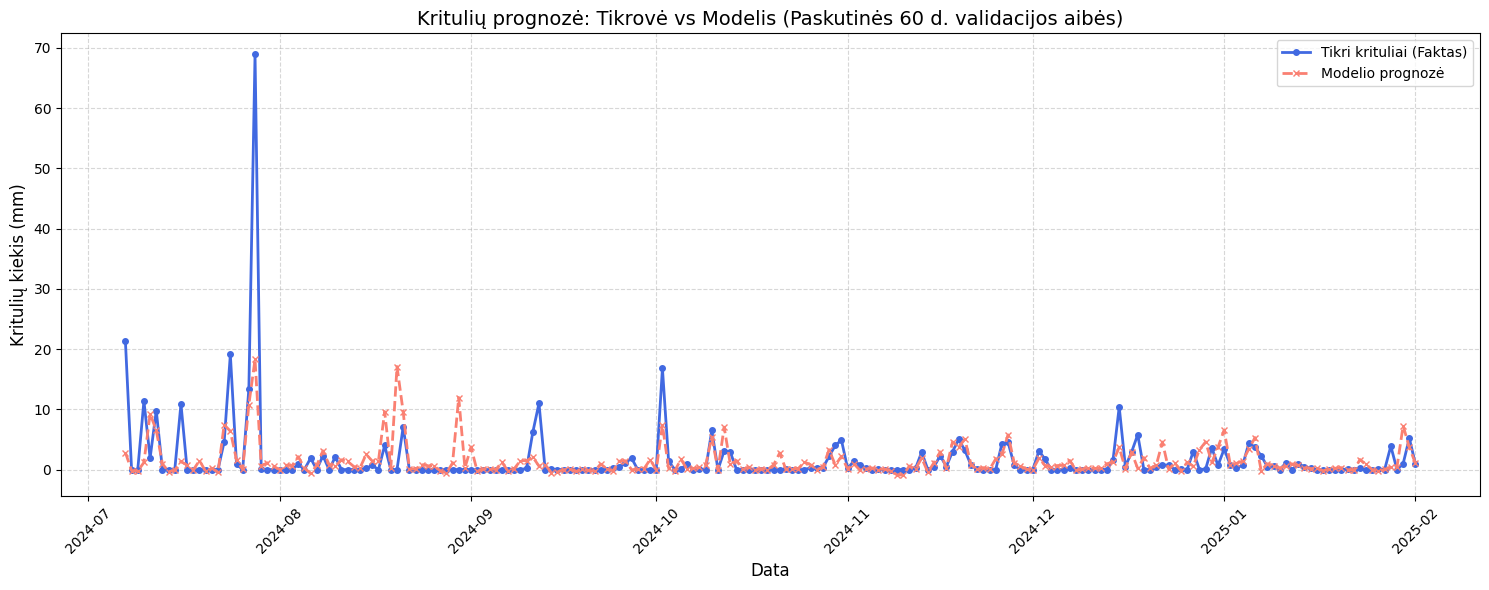

In [26]:
recent_df = plot_df.tail(210)

plt.figure(figsize=(15, 6))

# Tikri krituliai
plt.plot(recent_df['observationTime'], recent_df['target_precipitation'], 
         label='Tikri krituliai (Faktas)', color='royalblue', linewidth=2, marker='o', markersize=4)

# Modelio prognozė
plt.plot(recent_df['observationTime'], recent_df['prediction'], 
         label='Modelio prognozė', color='salmon', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('Kritulių prognozė: Tikrovė vs Modelis (Paskutinės 60 d. validacijos aibės)', fontsize=14)
plt.ylabel('Kritulių kiekis (mm)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45) # Pasukame datas, kad tilptų
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

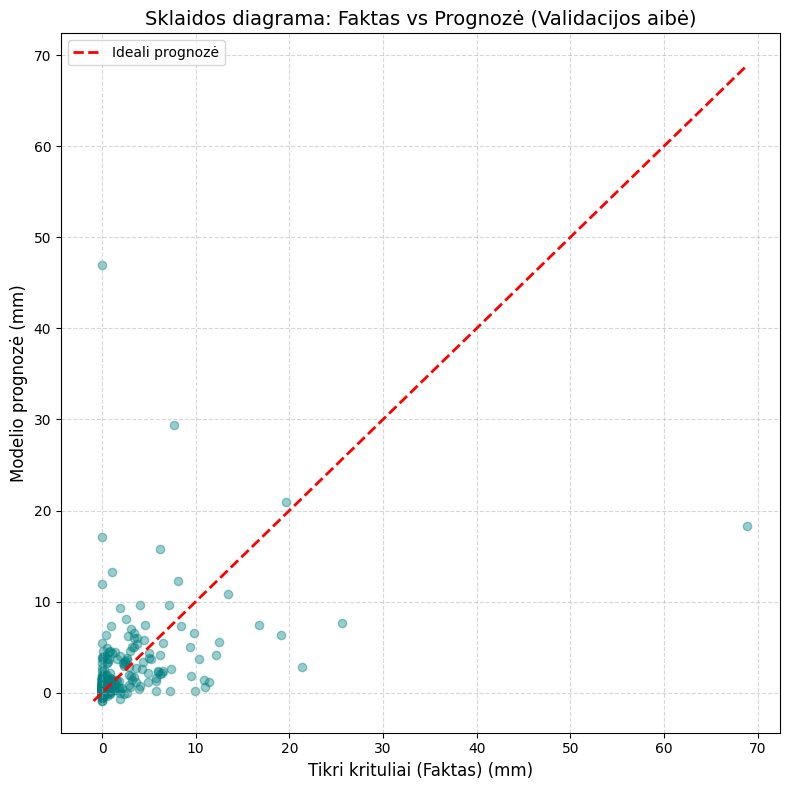

In [27]:
plt.figure(figsize=(8, 8))

plt.scatter(plot_df['target_precipitation'], plot_df['prediction'], alpha=0.4, color='teal')

max_val = max(plot_df['target_precipitation'].max(), plot_df['prediction'].max())
min_val = min(plot_df['target_precipitation'].min(), plot_df['prediction'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideali prognozė')

plt.title('Sklaidos diagrama: Faktas vs Prognozė (Validacijos aibė)', fontsize=14)
plt.xlabel('Tikri krituliai (Faktas) (mm)', fontsize=12)
plt.ylabel('Modelio prognozė (mm)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

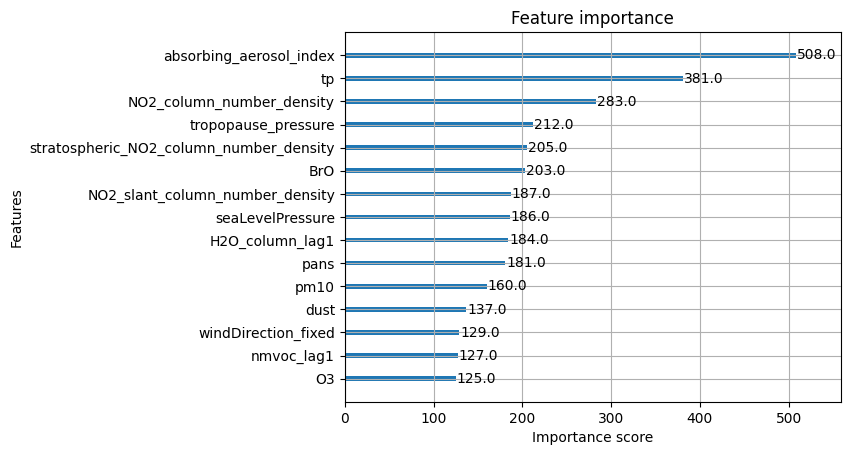

In [16]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(stand_model, max_num_features=15, importance_type='weight') 
plt.show()

c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


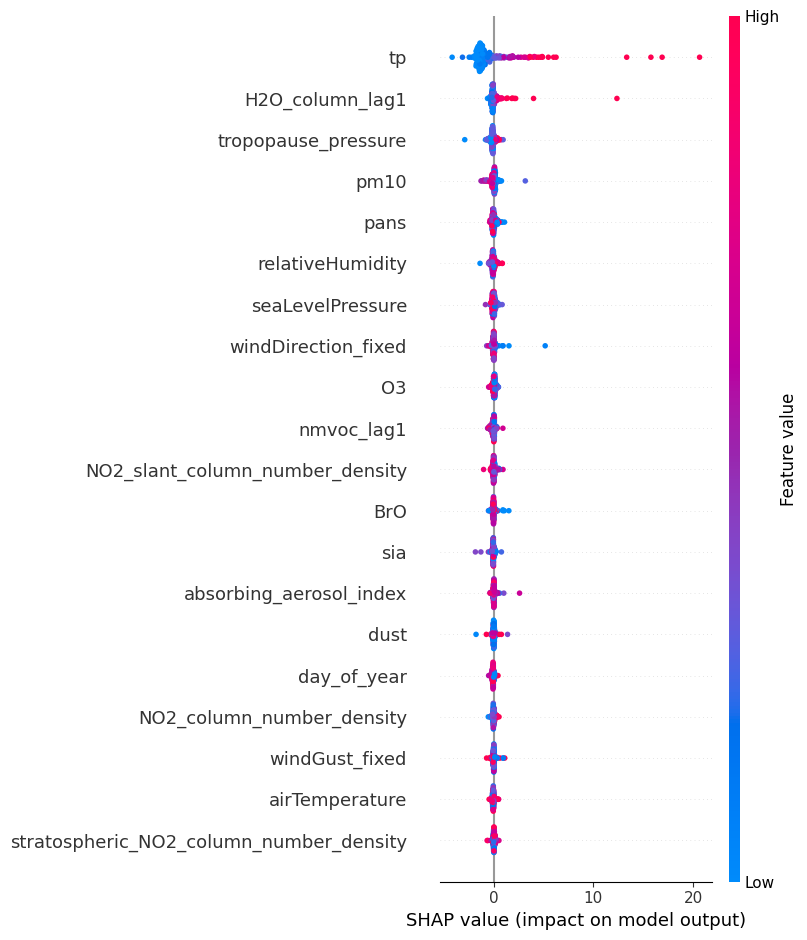

In [17]:
import shap

explainer = shap.TreeExplainer(stand_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)

## Hiperparametru atrinkimas

In [32]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=2026)

grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='r2',
    verbose=1, 
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print(f"Geriausi parametrai: {grid_search.best_params_}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Geriausi parametrai: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}


In [33]:
results_df = pd.DataFrame(grid_search.cv_results_)

important_columns = ['mean_test_score', 'std_test_score', 'params']
summary = results_df[important_columns].sort_values(by='mean_test_score', ascending=False)
summary.head()

,mean_test_score,std_test_score,params
5,0.396526,0.085128,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
18,0.396319,0.087438,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
36,0.395744,0.075037,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
19,0.394925,0.079851,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
4,0.390749,0.086531,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."


In [35]:
val_preds = stand_model.predict(X_val)

mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2 = r2_score(y_val, val_preds)
corr, p_value = spearmanr(y_val, val_preds)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Spearmano koreliacijos koeficientas: {corr:.3f}")

MAE: 1.5837
RMSE: 4.3583
R2: 0.4061
Spearmano koreliacijos koeficientas: 0.663


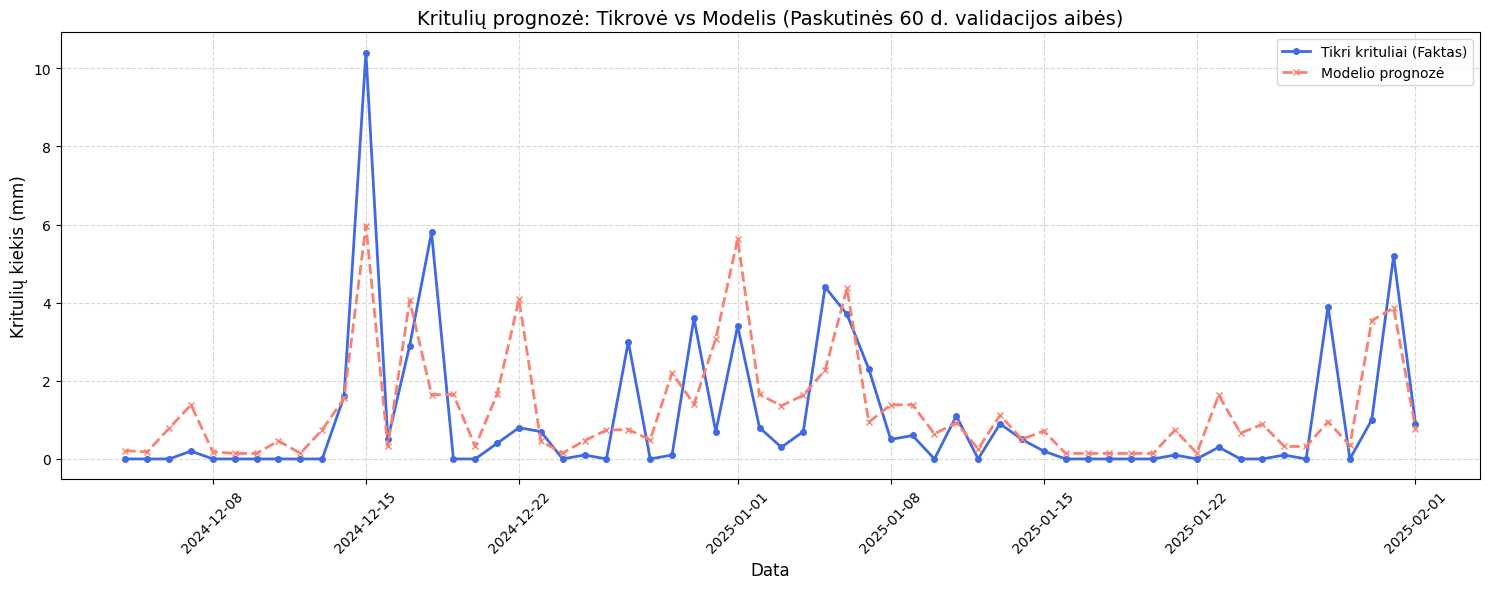

In [37]:
plot_df = val[['observationTime', 'target_precipitation']].copy()
plot_df['prediction'] = val_preds
plot_df = plot_df.sort_values('observationTime')

plt.figure(figsize=(15, 6))

plt.plot(recent_df['observationTime'], recent_df['target_precipitation'], 
         label='Tikri krituliai (Faktas)', color='royalblue', linewidth=2, marker='o', markersize=4)

plt.plot(recent_df['observationTime'], recent_df['prediction'], 
         label='Modelio prognozė', color='salmon', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('Kritulių prognozė: Tikrovė vs Modelis (Paskutinės 60 d. validacijos aibės)', fontsize=14)
plt.ylabel('Kritulių kiekis (mm)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()